In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class GaussianFourierProjection(nn.Module):
    def __init__(self, embed_dim=256, scale=30.0):
        super().__init__()
        self.W = nn.Parameter(torch.randn(embed_dim // 2) * scale, requires_grad=False)
    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)

class AdaptiveResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, embed_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()
        self.norm1 = nn.GroupNorm(num_groups=32, num_channels=in_channels)
        self.norm2 = nn.GroupNorm(num_groups=32, num_channels=out_channels)
        self.embed_layers = nn.ModuleList([nn.Linear(embed_dim, out_channels * 2)])
        self.act = nn.SiLU()

    def forward(self, x, embed):
        h = self.act(self.norm1(x))
        h = self.conv1(h)
        h = self.norm2(h)
        style = self.embed_layers[0](embed)
        style = style.view(style.shape[0], 2, -1, 1, 1)
        scale, shift = style[:, 0], style[:, 1]
        h = h * (1 + scale) + shift
        h = self.act(h)
        h = self.conv2(h)
        return h + self.shortcut(x)

class ConditionalScoreNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.noise_embed = nn.Sequential(
            GaussianFourierProjection(embed_dim=256),
            nn.Linear(256, 256),
            nn.SiLU()
        )
        
        self.class_embed = nn.Embedding(num_classes, 256)

        combined_embed_dim = 512
        
        self.input_conv = nn.Conv2d(1, 64, kernel_size=3, padding=1)

        self.enc1 = AdaptiveResBlock(64, 64, embed_dim=combined_embed_dim)
        self.down1 = nn.AvgPool2d(2)
        self.enc2 = AdaptiveResBlock(64, 128, embed_dim=combined_embed_dim)
        self.down2 = nn.AvgPool2d(2)
        self.enc3 = AdaptiveResBlock(128, 256, embed_dim=combined_embed_dim)
        
        self.dec1 = AdaptiveResBlock(256 + 128, 128, embed_dim=combined_embed_dim)
        self.dec2 = AdaptiveResBlock(128 + 64, 64, embed_dim=combined_embed_dim)
        
        self.output_conv = nn.Conv2d(64, 1, kernel_size=3, padding=1)

    def forward(self, x, sigma, y):
        e_sigma = self.noise_embed(sigma) # (B, 256)
        
        e_y = self.class_embed(y)         # (B, 256)

        embed = torch.cat([e_sigma, e_y], dim=1) # (B, 512)
        
        h = self.input_conv(x)
        h1 = self.enc1(h, embed)
        h = self.down1(h1)
        h2 = self.enc2(h, embed)
        h = self.down2(h2)
        h3 = self.enc3(h, embed)
        
        h_up1 = F.interpolate(h3, scale_factor=2, mode='nearest')
        h = torch.cat([h_up1, h2], dim=1)
        h = self.dec1(h, embed)
        
        h_up2 = F.interpolate(h, scale_factor=2, mode='nearest')
        h = torch.cat([h_up2, h1], dim=1)
        h = self.dec2(h, embed)
        
        out = self.output_conv(h)
        out = out / sigma[:, None, None, None]
        return out

In [5]:
sigma_begin = 30.0
sigma_end = 0.01
num_levels = 10
batch_size = 64
lr = 2e-4
epochs = 30
step_lr = 2e-5

sigmas = torch.exp(torch.linspace(np.log(sigma_begin), np.log(sigma_end), num_levels)).to(device)

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

cond_model = ConditionalScoreNet(num_classes=10).to(device)
optimizer = optim.Adam(cond_model.parameters(), lr=lr)

print("Starting Conditional Training...")
losses = []

for epoch in range(epochs):
    avg_loss = 0
    for i, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)
        
        rand_indices = torch.randint(0, num_levels, (x.size(0),), device=device)
        used_sigmas = sigmas[rand_indices].view(-1, 1, 1, 1)
        
        z = torch.randn_like(x)
        x_noisy = x + used_sigmas * z
        
        score_pred = cond_model(x_noisy, sigmas[rand_indices], y)
        target = -z / used_sigmas
        
        loss = 0.5 * ((score_pred - target) ** 2).sum(dim=(1, 2, 3)) * (used_sigmas.view(-1) ** 2)
        loss = loss.mean()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        avg_loss += loss.item()
        

    avg_loss = avg_loss / (i + 1)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    if epoch % 5 == 0:
        checkpoint = {
            'epoch': epochs,
            'model_state_dict': cond_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history': losses,
        }

        torch.save(checkpoint, f"cond_model_checkpoint_{epoch}.pth")


plt.figure()
plt.plot(losses, marker='o')
plt.title("Conditional Training Loss")
plt.show()

Starting Conditional Training...
Epoch 1, Loss: 41.6513
Epoch 2, Loss: 23.5018
Epoch 3, Loss: 22.0371
Epoch 4, Loss: 21.6588
Epoch 5, Loss: 21.0716
Epoch 6, Loss: 20.7792
Epoch 7, Loss: 20.5574
Epoch 8, Loss: 20.3470
Epoch 9, Loss: 20.2907
Epoch 10, Loss: 20.2522
Epoch 11, Loss: 20.0123
Epoch 12, Loss: 19.8435
Epoch 13, Loss: 19.5982
Epoch 14, Loss: 19.6562
Epoch 15, Loss: 19.5473
Epoch 16, Loss: 19.3603


KeyboardInterrupt: 

Loading Checkpoint...
Successfully loaded model from epoch 15
Resuming Conditional Training...


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9904\4242867228.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Epoch 17, Loss: 19.4097
Epoch 18, Loss: 19.2425
Epoch 19, Loss: 19.3052
Epoch 20, Loss: 19.2409
Epoch 21, Loss: 19.1939
Checkpoint saved: cond_model_checkpoint_20.pth
Epoch 22, Loss: 18.9742
Epoch 23, Loss: 18.9862
Epoch 24, Loss: 19.0543
Epoch 25, Loss: 19.0417
Epoch 26, Loss: 18.8596
Checkpoint saved: cond_model_checkpoint_25.pth
Epoch 27, Loss: 18.7389
Epoch 28, Loss: 18.7694
Epoch 29, Loss: 18.6927
Epoch 30, Loss: 18.6241


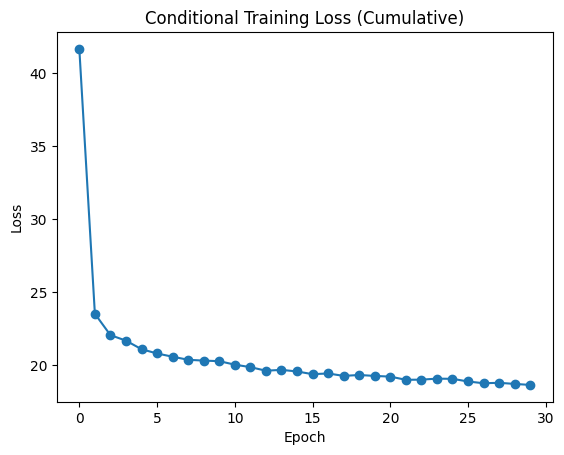

In [2]:
sigma_begin = 30.0
sigma_end = 0.01
num_levels = 10
batch_size = 64
lr = 2e-4
epochs = 30
step_lr = 2e-5
start_epoch = 16

sigmas = torch.exp(torch.linspace(np.log(sigma_begin), np.log(sigma_end), num_levels)).to(device)

transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
cond_model = ConditionalScoreNet(num_classes=10).to(device)

optimizer = optim.Adam(cond_model.parameters(), lr=lr)

print("Loading Checkpoint...")

try:
    checkpoint_path = "cond_model_checkpoint_15.pth"
    checkpoint = torch.load(checkpoint_path)

    cond_model.load_state_dict(checkpoint['model_state_dict'])

    if 'optimizer_state_dict' in checkpoint:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if 'loss_history' in checkpoint:
        losses = checkpoint['loss_history']
    else:
        losses = []

    print(f"Successfully loaded model from epoch {start_epoch-1}")

except FileNotFoundError:
    print("Error: Checkpoint file not found! Please check the file name.")
    losses = []
except RuntimeError as e:
    print(f"Error loading weights: {e}")
    print("Ensure you are loading the CONDITIONAL model weights, not the unconditional ones.")
    losses = []

print("Resuming Conditional Training...")

cond_model.train()

for epoch in range(start_epoch, epochs):
    avg_loss = 0
    for i, (x, y) in enumerate(train_loader):
        x = x.to(device)
        y = y.to(device)
        
        rand_indices = torch.randint(0, num_levels, (x.size(0),), device=device)
        used_sigmas = sigmas[rand_indices].view(-1, 1, 1, 1)
        
        z = torch.randn_like(x)
        x_noisy = x + used_sigmas * z
        
        score_pred = cond_model(x_noisy, sigmas[rand_indices], y)
        target = -z / used_sigmas
        
        loss = 0.5 * ((score_pred - target) ** 2).sum(dim=(1, 2, 3)) * (used_sigmas.view(-1) ** 2)
        loss = loss.mean()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        avg_loss += loss.item()
        
    avg_loss = avg_loss / (i + 1)
    losses.append(avg_loss)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
    
    if epoch % 5 == 0:
        checkpoint_save = {
            'epoch': epoch,
            'model_state_dict': cond_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history': losses,
        }
        torch.save(checkpoint_save, f"cond_model_checkpoint_{epoch}.pth")
        print(f"Checkpoint saved: cond_model_checkpoint_{epoch}.pth")

plt.figure()
plt.plot(losses, marker='o')
plt.title("Conditional Training Loss (Cumulative)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [4]:
checkpoint_save = {
            'epoch': epochs,
            'model_state_dict': cond_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss_history': losses,
        }
torch.save(checkpoint_save, "cond_model_final.pth")
print("Checkpoint saved")

Checkpoint saved


Generating Conditional Samples for 10 digits...


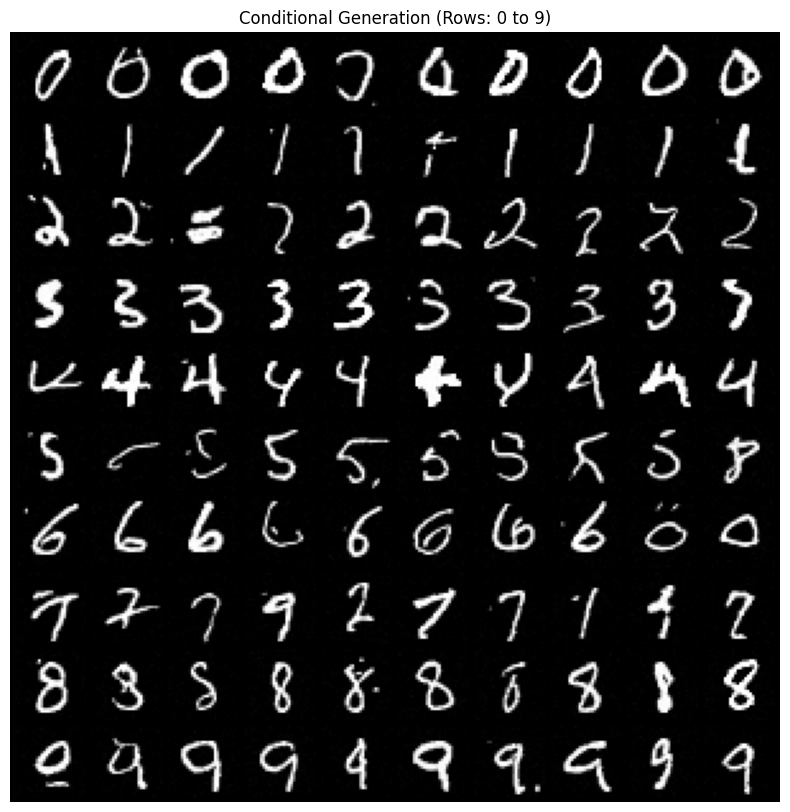

In [5]:
def conditional_langevin_dynamics(model, sigmas, target_y, steps_per_level=100, step_lr=2e-5):
    n_samples = target_y.size(0)
    x = torch.rand(n_samples, 1, 28, 28).to(device)
    
    model.eval()
    with torch.no_grad():
        for i, sigma in enumerate(sigmas):
            alpha = step_lr * (sigma / sigmas[-1]) ** 2
            for t in range(steps_per_level):
                sigma_input = torch.ones(n_samples, device=device) * sigma

                score = model(x, sigma_input, target_y)
                
                z = torch.randn_like(x)
                if i == len(sigmas) - 1 and t == steps_per_level - 1:
                    z = 0
                
                x = x + alpha / 2 * score + torch.sqrt(alpha) * z
                
    return x.clamp(0, 1)

rows = 10
cols = 10
target_labels = []
for digit in range(rows):
    target_labels.extend([digit] * cols)

target_y = torch.tensor(target_labels).to(device)

print(f"Generating Conditional Samples for {rows} digits...")
cond_samples = conditional_langevin_dynamics(cond_model, sigmas, target_y, steps_per_level=100)

plt.figure(figsize=(10, 10))
grid_img = make_grid(cond_samples.cpu(), nrow=cols, padding=2, normalize=True)
plt.imshow(grid_img.permute(1, 2, 0))
plt.axis('off')
plt.title("Conditional Generation (Rows: 0 to 9)")
plt.savefig("conditional_grid.png")
plt.show()